In [13]:
from typing import Dict, List, Any
import numpy as np
from numpy.typing import NDArray
import pandas as pd

from model_ranking.results import (
    get_summary_results, 
    per_source_model_results,
)
from model_ranking.plots import plot_alpha_sweep_specific_norm
from model_ranking.correlation import (
    calculate_correlation_statistics
)

In [14]:
per_source_consis_result_type =  Dict[str, Dict[str, Dict[str, NDArray[Any]]]]
per_source_performance_result_type = Dict[str, Dict[str, float]]
per_target_consis_result_type = Dict[str, per_source_consis_result_type]
per_target_performance_result_type = Dict[str, per_source_performance_result_type]

# Settings

In [15]:
NA_source_models = {
    "EPFL": "E_model_NA2",
    "Hmito": "Hm_model_NA2",
    "Rmito": "Rm_model_NA2",
    "VNC": "V_model_NA2",
}
Res_source_models = {
    "EPFL": "E_model_Res1",
    "Hmito": "Hm_model_Res1",
    "Rmito": "Rm_model_Res1",
    "VNC": "V_model_Res1",
}
source_models={
    "EPFL": "E_model4",
    "Hmito": "Hm_model3",
    "Rmito": "Rm_model3",
    "VNC": "V_model1",
}
consis_keys={
    "EPFL": "EI_consis",
    "Hmito": "EI_consis",
    "Rmito": "EI_consis",
    "VNC": "EI_consis",
}
consis_keys_bckg = {
    "EPFL": "EI_consis_bckg",
    "Hmito": "EI_consis_bckg",
    "Rmito": "EI_consis_bckg",
    "VNC": "EI_consis_bckg",
}
consis_keys2 = {
    "EPFL": "EI_th05",
    "Hmito": "EI_th05",
    "Rmito": "EI_th05",
}
result_folders={
    "EPFL": "FP_3",
    "Hmito": "FP_3",
    "Rmito": "FP_3",
    "VNC": "FP_3",
}

per_target_norms: Dict[str, List[None]] = {
    "EPFL": [None],
    "Hmito": [None],
    "Rmito": [None],
    "VNC": [None],
}

perf_key = "hard_f1"
approach="feature_perturbation_consistency"
base_result_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"

# Get Results

In [16]:
summary_results_postfix = "_full"
selected_augmentations = {
    "none": [""],
    "DO": ["a0005", "a001", "a005", "a01", "a02", "a03", "a04", "a05"],
}
targets = ["EPFL", "Hmito", "Rmito"]

### Foreground Consistency

In [17]:
per_target_forg_consistency= {}
per_target_forg_performance = {}
for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["EPFL", "Hmito", "Rmito"]
    else:
        sources = ["EPFL", "Hmito", "Rmito", "VNC"]
    per_source_forg_consistency= {}
    per_source_forg_performance = {}

    ### No Augmentation Models
    consis_str_NAmodels, _, NA_perf_NAmodels = get_summary_results(
        source_data=sources,
        target_data=[target],
        source_models = NA_source_models,
        selected_augmentations=selected_augmentations,
        selected_norms=per_target_norms,
        consis_keys=consis_keys,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix="median",
        perf_postfix="median",
        summary_results_postfix=summary_results_postfix,
        base_seg_dir=base_result_path,
    )
    per_source_forg_consistency.update(
        per_source_model_results(
            consis_str_NAmodels, 
            source_models=NA_source_models, 
        ))
    per_source_forg_performance.update(
        per_source_model_results(
            NA_perf_NAmodels, 
            source_models=NA_source_models,
        ))
    
    ### Residual UNet Models
    consis_str_Resmodels, _, NA_perf_Resmodels = get_summary_results(
        source_data=sources,
        target_data=[target],
        source_models = Res_source_models,
        selected_augmentations=selected_augmentations,
        selected_norms=per_target_norms,
        consis_keys=consis_keys,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix="median",
        perf_postfix="median",
        summary_results_postfix=summary_results_postfix,
        base_seg_dir=base_result_path,
    )
    per_source_forg_consistency.update(
        per_source_model_results(
            consis_str_Resmodels, 
            source_models=Res_source_models, 
        ))
    per_source_forg_performance.update(
        per_source_model_results(
            NA_perf_Resmodels, 
            source_models=Res_source_models,
        ))
    
    ### UNet Models
    if target == "VNC":
        consis_str, _, NA_perf = get_summary_results(
            source_data=["EPFL", "Hmito", "Rmito"],
            target_data=[target],
            source_models=source_models,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders={"VNC": "resized"},
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
    else:
        consis_str, _, NA_perf = get_summary_results(
            source_data=["EPFL", "Hmito", "Rmito"],
            target_data=[target],
            source_models=source_models,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys2,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        consis_str_VNC, _, NA_per_VNC = get_summary_results(
            source_data=["VNC"],
            target_data=[target],
            source_models=source_models,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        consis_str.update(consis_str_VNC)
        NA_perf.update(NA_per_VNC)
    
    per_source_forg_consistency.update(
        per_source_model_results(
            consis_str, 
            source_models=source_models,
        ))
    per_source_forg_performance.update(
        per_source_model_results(
            NA_perf,
            source_models=source_models,
        ))

    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 21.18it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 22.62it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 18.92it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 18.72it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00,  6.63it/s]


### Background Consistency

In [18]:
per_target_bckg_consistency: Dict[str, Dict[str, Dict[str, Dict[str, NDArray[Any]]]]] = {}
per_target_bckg_performance: Dict[str, Dict[str, Dict[str, NDArray[Any]]]] = {}

for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["EPFL", "Hmito", "Rmito"]
    else:
        sources = ["EPFL", "Hmito", "Rmito", "VNC"]
    per_source_bckg_consistency = {}
    per_source_bckg_performance = {}

    ### No Augmentation Models
    consis_str_NAmodels, _, NA_perf_NAmodels = get_summary_results(
        source_data=sources,
        target_data=[target],
        source_models = NA_source_models,
        selected_augmentations=selected_augmentations,
        selected_norms=per_target_norms,
        consis_keys=consis_keys_bckg,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix="median",
        perf_postfix="median",
        summary_results_postfix=summary_results_postfix,
        base_seg_dir=base_result_path,
    )
    per_source_bckg_consistency.update(
        per_source_model_results(
            consis_str_NAmodels, 
            source_models=NA_source_models, 
        ))
    per_source_bckg_performance.update(
        per_source_model_results(
            NA_perf_NAmodels, 
            source_models=NA_source_models,
        ))
    
    ### Residual UNet Models
    consis_str_Resmodels, _, NA_perf_Resmodels = get_summary_results(
        source_data=sources,
        target_data=[target],
        source_models = Res_source_models,
        selected_augmentations=selected_augmentations,
        selected_norms=per_target_norms,
        consis_keys=consis_keys_bckg,
        perf_key=perf_key,
        per_target_norms=True,
        result_folders=result_folders,
        approach=approach,
        consis_postfix="median",
        perf_postfix="median",
        summary_results_postfix=summary_results_postfix,
        base_seg_dir=base_result_path,
    )
    per_source_bckg_consistency.update(
        per_source_model_results(
            consis_str_Resmodels, 
            source_models=Res_source_models, 
        ))
    per_source_bckg_performance.update(
        per_source_model_results(
            NA_perf_Resmodels, 
            source_models=Res_source_models,
        ))
    
    ### UNet Models
    if target == "VNC":
        consis_str, _, NA_perf = get_summary_results(
            source_data=["EPFL", "Hmito", "Rmito"],
            target_data=[target],
            source_models=source_models,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys_bckg,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders={"VNC": "resized"},
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
    else:
        consis_str, _, NA_perf = get_summary_results(
            source_data=["EPFL", "Hmito", "Rmito", "VNC"],
            target_data=[target],
            source_models=source_models,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys_bckg,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )

    per_source_bckg_consistency.update(
        per_source_model_results(
            consis_str, 
            source_models=source_models,
        ))
    per_source_bckg_performance.update(
        per_source_model_results(
            NA_perf,
            source_models=source_models,
        ))

    per_target_bckg_consistency[target] = per_source_bckg_consistency
    per_target_bckg_performance[target] = per_source_bckg_performance

    

Source: EPFL


100%|██████████| 1/1 [00:00<00:00, 28.46it/s]


Source: Hmito


100%|██████████| 1/1 [00:00<00:00, 29.81it/s]


Source: Rmito


...

100%|██████████| 1/1 [00:00<00:00, 23.34it/s]


Source: Rmito


100%|██████████| 1/1 [00:00<00:00, 22.59it/s]


Source: VNC


100%|██████████| 1/1 [00:00<00:00, 24.98it/s]


# Combined Consistency Score and ranking

### Weighted Classwise Average

In [19]:
def consistency_score_weighted_average(
    foreground_consistency: per_target_consis_result_type,
    background_consistency: per_target_consis_result_type,
    w_fg: float = 0.5,
    w_bg: float = 0.5,
):
    per_target_cmb_consistency: per_target_consis_result_type = {}
    for target in foreground_consistency.keys():
        per_model_cmb_consistency = {}
        for model in foreground_consistency[target].keys():
            bckg_consis = background_consistency[target][model]["norm_Normalize"]["DO"]
            forg_consis = foreground_consistency[target][model]["norm_Normalize"]["DO"]
            cmb_consis = (w_fg * forg_consis + w_bg * bckg_consis) / (w_fg + w_bg)
            per_model_cmb_consistency[model] = {"norm_Normalize": {"DO": cmb_consis}}
        per_target_cmb_consistency[target] = per_model_cmb_consistency
    return per_target_cmb_consistency

In [20]:
per_target_cmb_consistency = consistency_score_weighted_average(
    per_target_forg_consistency,
    per_target_bckg_consistency,
    w_fg=0.5,
    w_bg=0.5,
)

In [21]:
per_target_KT = np.zeros((len(targets), len(selected_augmentations["DO"]), 2))
per_target_SP = np.zeros((len(targets), len(selected_augmentations["DO"]), 2))
per_target_PE = np.zeros((len(targets), len(selected_augmentations["DO"]), 2))
for i, target in enumerate(targets):
    (per_target_KT[i], 
        per_target_SP[i], 
        per_target_PE[i]
    ) = calculate_correlation_statistics(
            per_target_cmb_consistency[target],
            per_target_forg_performance[target],
            selected_augmentations,
            perturbation_key="DO",
        )

In [22]:
per_target_KT.shape

(3, 8, 2)

In [23]:
aug_strengths = selected_augmentations["DO"]
for aug_strength in aug_strengths:
    idx = selected_augmentations["DO"].index(aug_strength)
    df = pd.DataFrame(
        {
            "kt": per_target_KT[:, idx, 0], 
            "kt pval": per_target_KT[:, idx, 1], 
            "s rho": per_target_SP[:, idx, 0], 
            "s rho pval": per_target_SP[:, idx, 1], 
            "pr": per_target_PE[:, idx, 0], 
            "pr pval": per_target_PE[:, idx, 1]
        },
    )
    df["targets"] = targets
    df = df.set_index("targets")
    df.index = pd.MultiIndex.from_product([["Mito"], df.index], names=["Task", "targets"])
    # Round all float columns to 2 significant figures
    df = df.map(lambda x: round(x, 2) if isinstance(x, float) else x)
    print(f"Augmentation strength: DO {aug_strength}")
    print(df)

Augmentation strength: DO a0005
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.78     0.00   0.86        0.00  0.73     0.00
     Hmito    0.62     0.03   0.69        0.01  0.45     0.05
     Rmito    0.84     0.00   0.79        0.00  0.60     0.01
Augmentation strength: DO a001
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.79     0.00   0.90        0.00  0.76     0.00
     Hmito    0.65     0.02   0.71        0.01  0.48     0.04
     Rmito    0.86     0.00   0.82        0.00  0.63     0.01
Augmentation strength: DO a005
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.83     0.00   0.93         0.0  0.79      0.0
     Hmito    0.71     0.01   0.85         0.0  0.70      0.0
     Rmito    0.84     0.00   0.87    

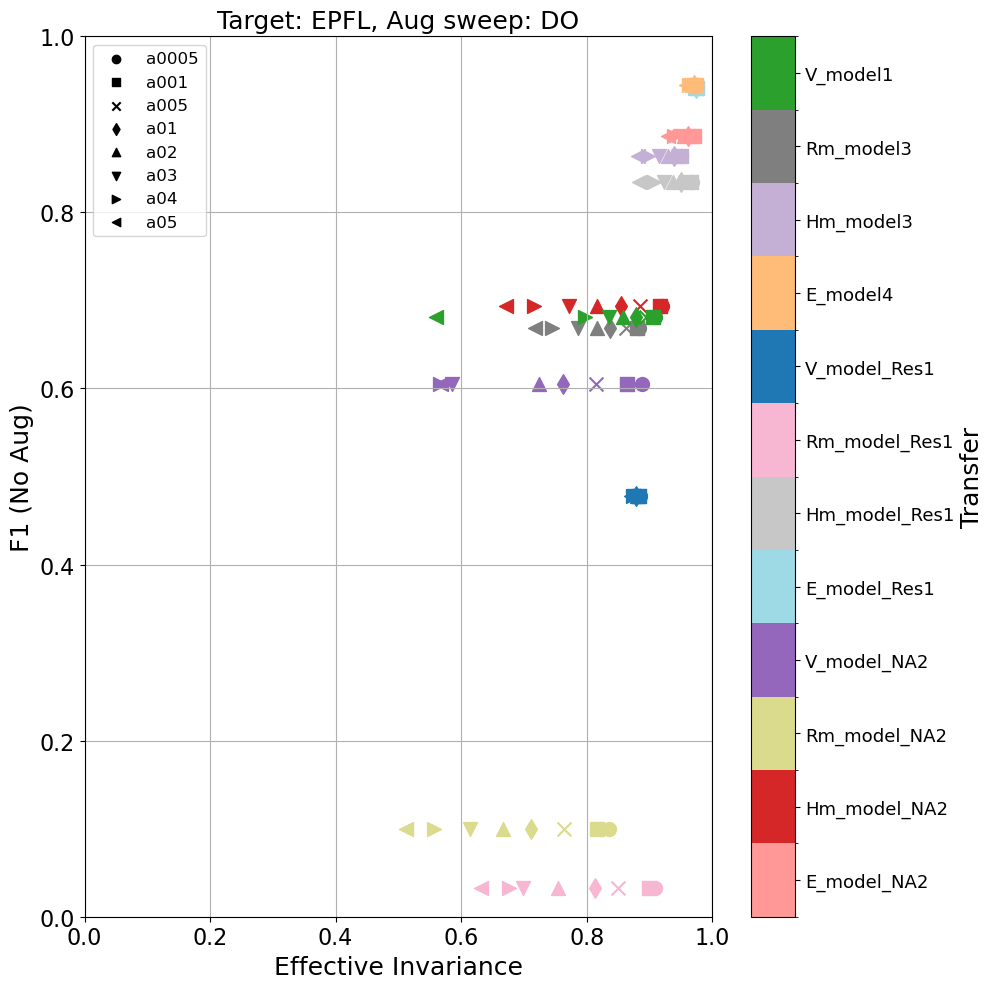

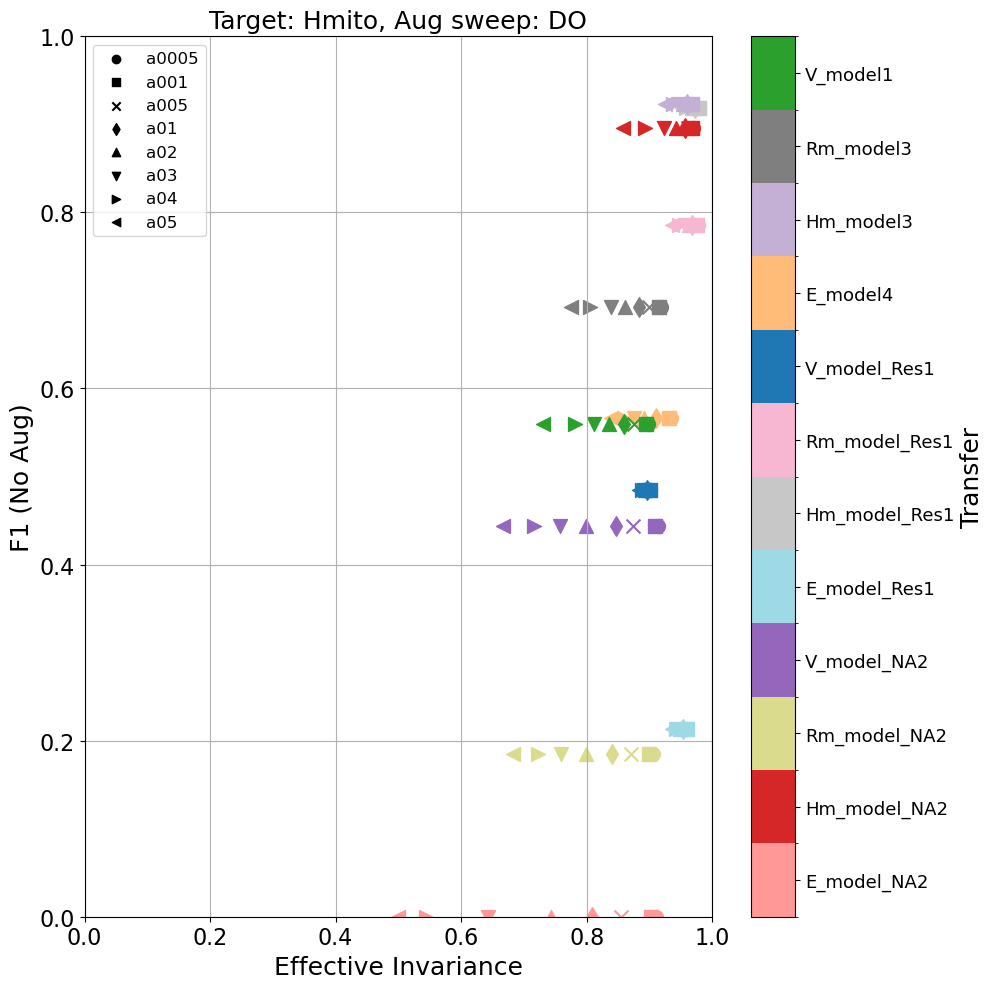

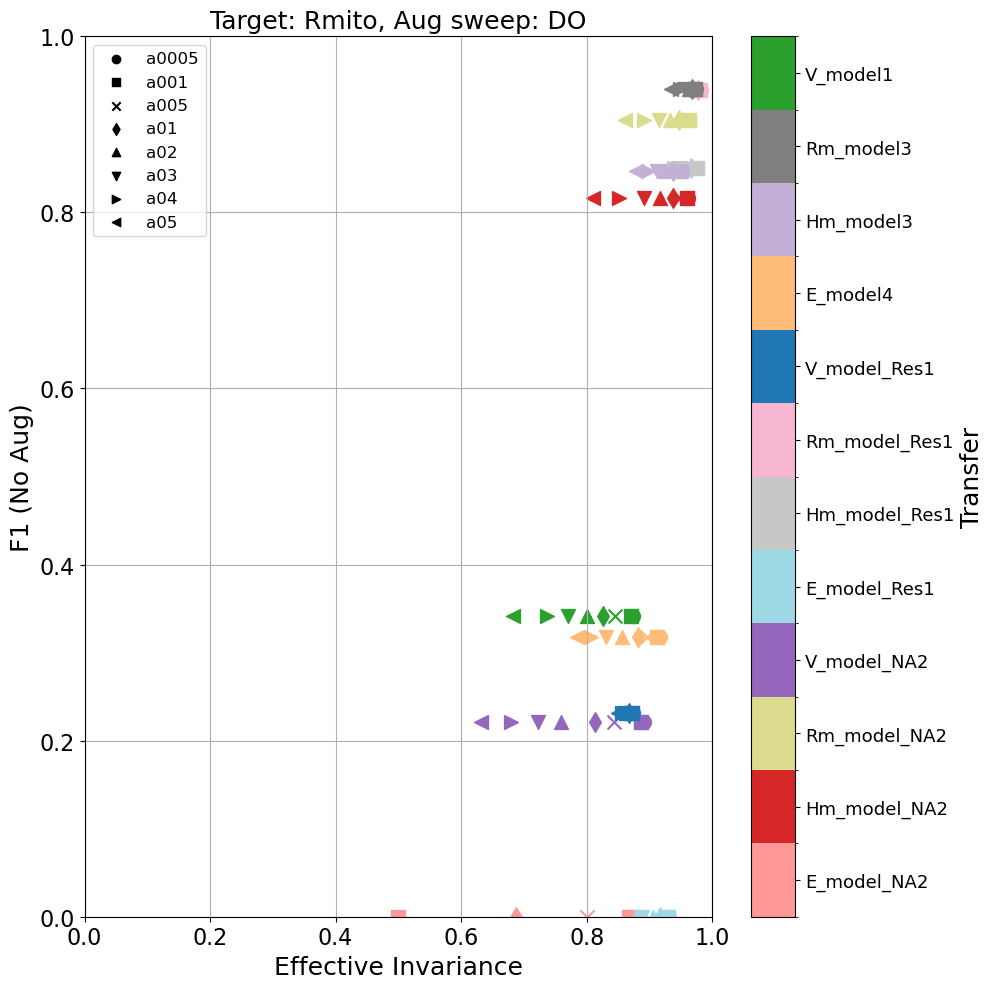

In [24]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_cmb_consistency[target],
        per_target_forg_performance[target],
        augs=["DO"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )
(
    pearson_scores, 
    spearman_scores, 
    kendall_tau_scores
) = calculate_correlation_statistics(
        per_target_cmb_consistency[target],
        per_target_forg_performance[target],
        selected_augmentations,
        perturbation_key="DO",
    )


# Foreground/Background weighting

In [36]:
from tqdm import tqdm
import matplotlib.pyplot as plt

In [35]:
weight_pairs = [(0.5, 0.5), (0.6, 0.4), (0.666666, 0.333333), (0.7, 0.3), (0.75, 0.25), (0.8, 0.2), (0.9, 0.1)]


KT_scores = []
SP_scores = []
PE_scores = []
for w_fg, w_bg in tqdm(weight_pairs):
    per_target_cmb_consistency = consistency_score_weighted_average(
        per_target_forg_consistency,
        per_target_bckg_consistency,
        w_fg=w_fg,
        w_bg=w_bg,
    )

    per_target_KT = np.zeros((len(targets), len(selected_augmentations["DO"]), 2))
    per_target_SP = np.zeros((len(targets), len(selected_augmentations["DO"]), 2))
    per_target_PE = np.zeros((len(targets), len(selected_augmentations["DO"]), 2))
    for i, target in enumerate(targets):
        (per_target_KT[i], 
            per_target_SP[i], 
            per_target_PE[i]
        ) = calculate_correlation_statistics(
                per_target_cmb_consistency[target],
                per_target_forg_performance[target],
                selected_augmentations,
                perturbation_key="DO",
            )
    KT_scores.append(per_target_KT)
    SP_scores.append(per_target_SP)
    PE_scores.append(per_target_PE)

100%|██████████| 7/7 [01:52<00:00, 16.06s/it]


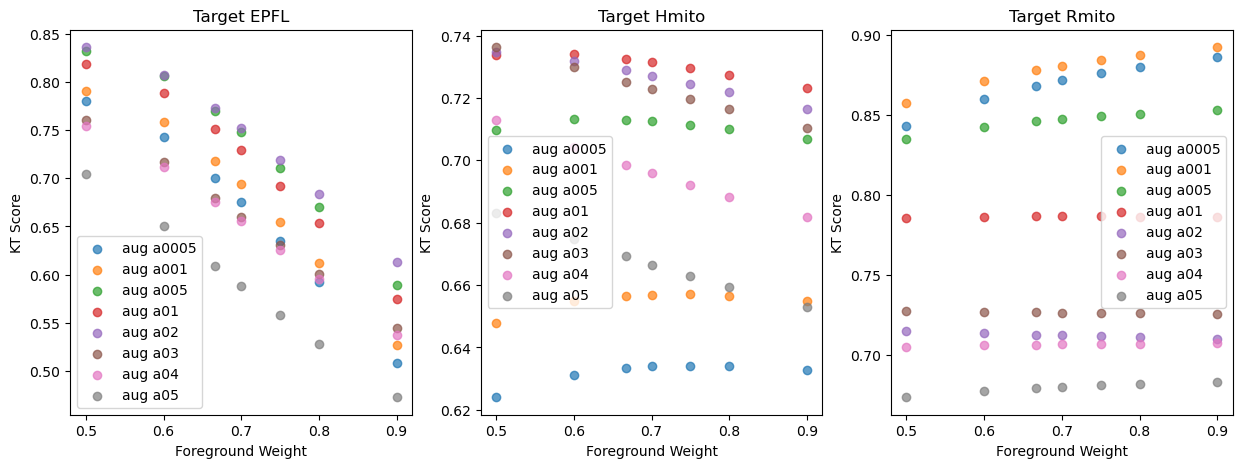

In [44]:
targets = ["EPFL", "Hmito", "Rmito"]
_, axs = plt.subplots(1, 3, figsize=(15, 5))
axs = axs.flatten()
for i, target in enumerate(targets):
    for k, aug in enumerate(selected_augmentations["DO"]):
        # For each augmentation, plot all weight pairs for the current target
        axs[i].scatter(
            [w[0] for w in weight_pairs],
            [KT_scores[j][i, k, 0] for j in range(len(weight_pairs))],
            label=f"aug {aug}",
            alpha=0.7
        )
    axs[i].set_title(f"Target {target}")
    axs[i].set_xlabel("Foreground Weight")
    axs[i].set_ylabel("KT Score")
    axs[i].legend()
plt.show()

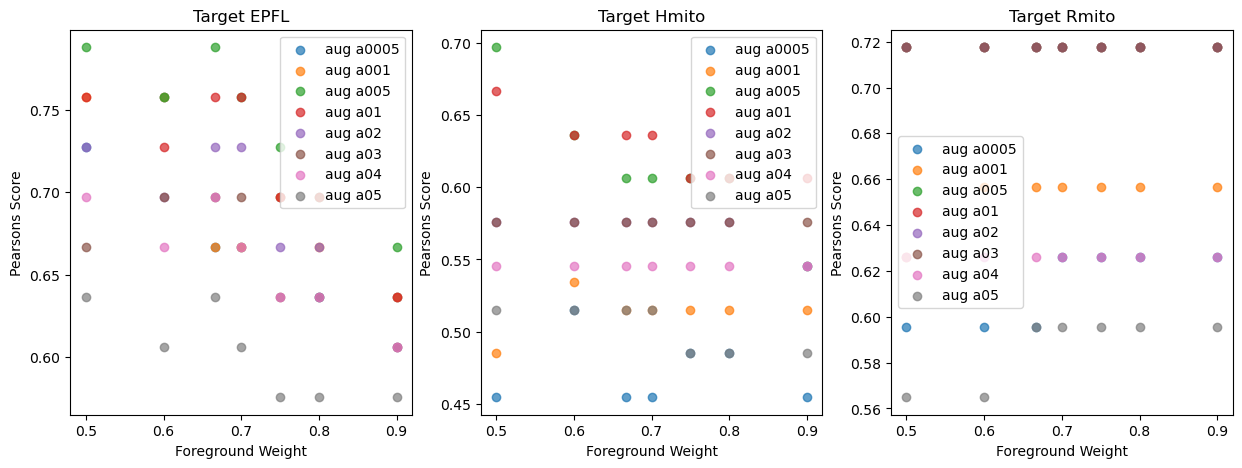

In [45]:
targets = ["EPFL", "Hmito", "Rmito"]
_, axs = plt.subplots(1, 3, figsize=(15, 5))
axs = axs.flatten()
for i, target in enumerate(targets):
    for k, aug in enumerate(selected_augmentations["DO"]):
        # For each augmentation, plot all weight pairs for the current target
        axs[i].scatter(
            [w[0] for w in weight_pairs],
            [PE_scores[j][i, k, 0] for j in range(len(weight_pairs))],
            label=f"aug {aug}",
            alpha=0.7
        )
    axs[i].set_title(f"Target {target}")

    axs[i].set_xlabel("Foreground Weight")
    axs[i].set_ylabel("Pearsons Score")
    axs[i].legend()
plt.show()

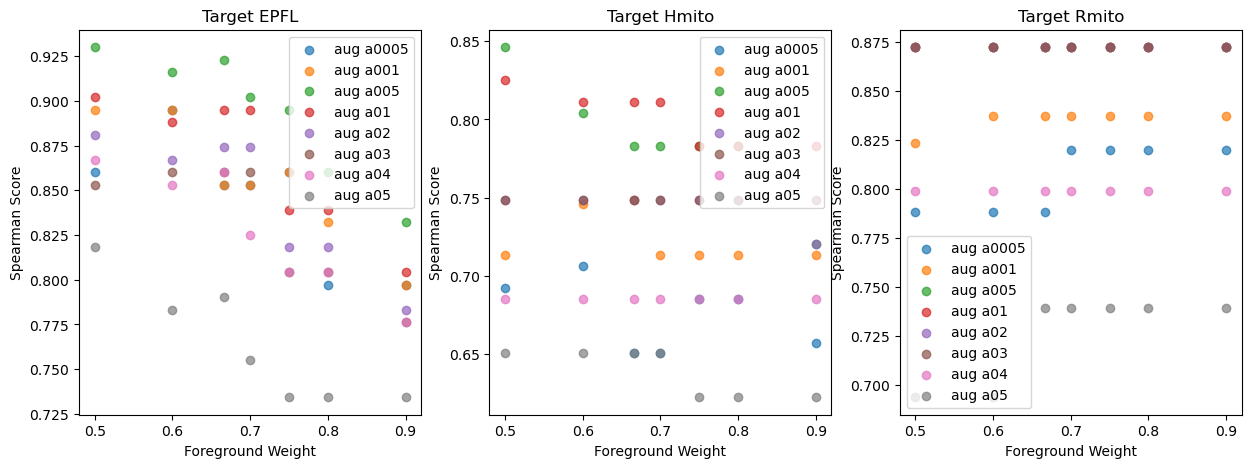

In [46]:
targets = ["EPFL", "Hmito", "Rmito"]
_, axs = plt.subplots(1, 3, figsize=(15, 5))
axs = axs.flatten()
for i, target in enumerate(targets):
    for k, aug in enumerate(selected_augmentations["DO"]):
        # For each augmentation, plot all weight pairs for the current target
        axs[i].scatter(
            [w[0] for w in weight_pairs],
            [SP_scores[j][i, k, 0] for j in range(len(weight_pairs))],
            label=f"aug {aug}",
            alpha=0.7
        )
    axs[i].set_title(f"Target {target}")
    axs[i].set_xlabel("Foreground Weight")
    axs[i].set_ylabel("Spearman Score")
    axs[i].legend()
plt.show()